In [59]:
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import pprint
from sam2.addons import read_vsi

In [94]:
file_path = Path("data/245/245_008.vsi")

meta, _ = read_vsi(file_path, load_image=False)

for scene in meta["scenes"]:
    meta_scene, _ = read_vsi(file_path, scene=scene, load_image=False)
    print(scene, meta_scene["shape"])

Acquisition (1, 1, 1, 3778, 18238)
245_008.vsi #2 (1, 1, 1, 1889, 9119)
245_008.vsi #3 (1, 1, 1, 945, 4560)
245_008.vsi #4 (1, 1, 1, 473, 2280)
245_008.vsi #5 (1, 1, 1, 237, 1140)
245_008.vsi #6 (1, 1, 1, 119, 570)
245_008.vsi #7 (1, 1, 1, 60, 285)
macro image (1, 1, 1, 106, 512, 3)


In [98]:
# choose scene (prefer Acquisition, otherwise MIA)
scene = next((s for s in meta["scenes"] if s in ("Acquisition", "MIA", "DIC/POL")), None)

if scene is None:
    raise RuntimeError("No 'Acquisition' or 'MIA' scene found in VSI file")


# load the selected scene
meta, img = read_vsi(file_path, scene=scene, load_image=True)

print(f"Loaded scene: {scene}")
print(f"Raw shape: {img.shape} as {img.dtype}")

# image layout: (T, C, Z, Y, X)
img = img[0, 0, 0, :, :]

print(f"2D image shape: {img.shape} as {img.dtype}")

pprint.pprint(meta)

Loaded scene: Acquisition
Raw shape: (1, 1, 1, 3778, 18238) as uint8
2D image shape: (3778, 18238) as uint8
{'bioformats_raw_metadata': OME(
   instruments=[<1 field_type>],
   images=[<8 field_type>],
),
 'channels': [np.str_('Channel:0:0')],
 'current_scene': 'Acquisition',
 'dims_order': '<Dimensions [T: 1, C: 1, Z: 1, Y: 3778, X: 18238]>',
 'dtype': 'uint8',
 'file_path': 'data/245/245_008.vsi',
 'ome': {'pixel_type': 'PixelType.UINT8',
         'size_c': 1,
         'size_t': 1,
         'size_x': 18238,
         'size_y': 3778,
         'size_z': 1},
 'physical_pixel_sizes': {'X': 0.11688678457992144,
                          'Y': 0.11688678457992144,
                          'Z': None,
                          'unit': 'µm (usually)'},
 'scenes': ['Acquisition',
            '245_008.vsi #2',
            '245_008.vsi #3',
            '245_008.vsi #4',
            '245_008.vsi #5',
            '245_008.vsi #6',
            '245_008.vsi #7',
            'macro image'],
 'shape': 

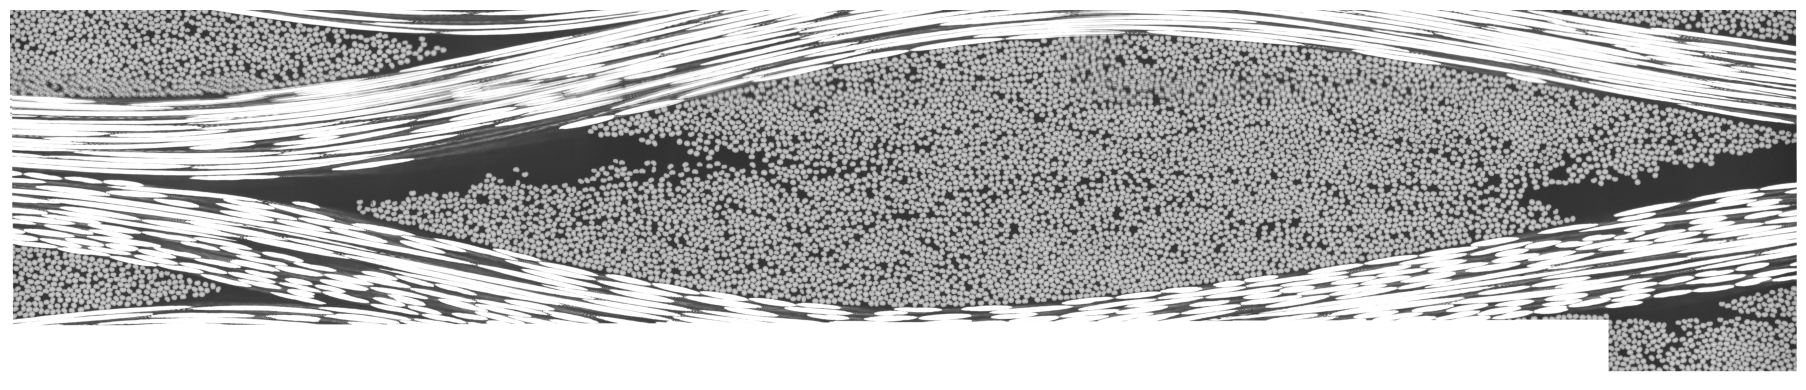

In [99]:
plt.figure(figsize=(20, 4))
plt.imshow(img, cmap="gray")
plt.axis("off")
plt.tight_layout()
plt.show()

In [100]:
output_path = file_path.parent / f"{file_path.stem}.tiff"

Image.fromarray(img).save(output_path)

print(f"Saved {file_path.stem}.tiff in {file_path.parent}")

Saved 245_008.tiff in data/245
